<a href="https://colab.research.google.com/github/JingyuHe02/COMP3132/blob/main/Assignment3/Assignment03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 03

The following assignment is divided in two parts:
- Part A: Run the cells that have already been coded for you to see and understand how Convolution 2D kernel works and, at the end, respond to the questions 1a, 1b, 2a, 2b
- Part B:  Run the cells that have already been coded for you to train the given Neural Network and then respond to the questions 03 to 10 in your video

**Note:**

Coding: 5%
video presentation: 5%
Total: 10%
But without YouTube presentation you receive no mark for the submission. In short, only submissions with YouTube link will be marked.

# PART A

## Image Convolution

In [1]:
# Import the necessary packages and libraries
import numpy as np
from PIL import Image
from scipy import misc
from skimage import data
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
%matplotlib inline
import requests
from io import BytesIO

/tmp/ipykernel_591/2672511126.py:4: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


## Import the image

In [2]:
# Get the image from the URL
response = requests.get('https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTAHCp2ppBbfcPk9S5nE8gFFsZpDh0Exv9qUKXjehk_QszZHsV_pw&s')

In [3]:
# Visualize the content of the response
print(response.content)

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x12\x13\x12\x15\x13\x13\x12\x16\x16\x15\x15\x17\x17\x16\x15\x17\x18\x17\x17\x17\x17\x17\x17\x15\x15\x16\x17\x15\x17\x15\x19\x19\x1d( \x18\x1b&\x1b\x15\x15!1!%)+...\x17\x1f383-7(-.+\x01\n\n\n\x0e\r\x0e\x1a\x10\x10\x1b-&\x1e%--------------------+--//--------/----------------\xff\xc0\x00\x11\x08\x00\x8c\x01g\x03\x01\x11\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x01\x05\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x02\x03\x04\x05\x06\x01\x07\x08\xff\xc4\x00L\x10\x00\x02\x00\x03\x05\x04\x06\x06\x05\t\x06\x05\x05\x01\x00\x00\x01\x02\x00\x03\x11\x04\x05\x12!1\x06AQq\x07\x13a\x81\x91\xa1"2Br\xb1\xc1#R\xd1\xe1\xf03Cb\x82\x92\xa2\xb2\xc2\xd2\x08\x14DSs\x93\x16\x17ET\xf14c\xa3\xb3\xe2\x15\xff\xc4\x00\x1b\x01\x01\x00\x03\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\xff\xc4\x00<\x11\x00\x02\x01\x02\x02\x06\x06\n\x00\x04\x07\x01\x00\x00\x00\

In [4]:
# BytesIO() buffers the image into the RAM
# Image.open() opens the buffered image
# np.array() transforms the image into a 3D array containing values from 0-255 corresponding to the RGB colour channels
input_img_arr = np.array(Image.open(BytesIO(response.content)))

## First let’s see the Image.




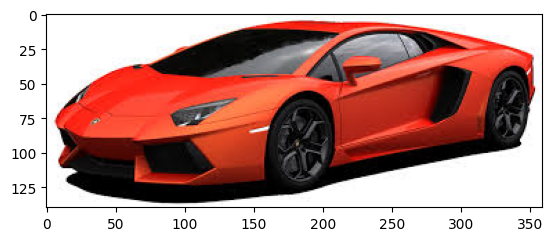

In [5]:
# Plot the resulting image from the array
plt.imshow(input_img_arr)

In [6]:
# Print the array shape
print(input_img_arr.shape)

# Compare the values of colour channels 0 and 1
print(np.array_equal(
        input_img_arr[:, :, 0],
        input_img_arr[:, :, 1]))

# Compare the values of colour channels 1 and 2
print(np.array_equal(
        input_img_arr[:, :, 1],
        input_img_arr[:, :, 2]))

(140, 359, 3)
False
False


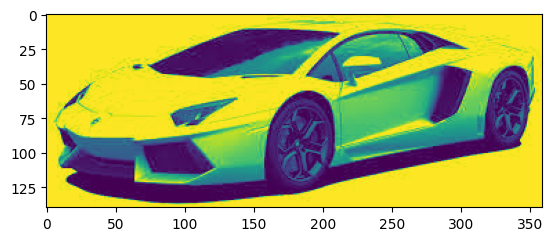

In [7]:
# Save the colour channel 0 in to the input_img_arr array variable and print it
input_img_arr = input_img_arr[:, :, 0]
plt.imshow(input_img_arr)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
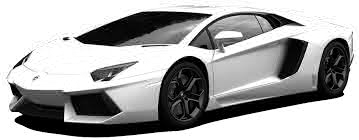

In [8]:
# Visualize the values inside of the resulting array
input_img_arr[:, :]

## Convolution with 2-D Kernels

How Convolution works?
https://miro.medium.com/max/790/1*1okwhewf5KCtIPaFib4XaA.gif

In [9]:
# Create a padded array by adding 2 rows and 2 columns (one of each at the beginning and another of each at the end)
padded_array = np.pad(input_img_arr, (1, 1), 'constant')

# Create the kernel
kernel = np.array([[0, 0, 0],
                   [0, 1, 0],
                   [0, 0, 0]])

#Create an output array filled with zeros with the same shape of input_img_arr
output_array = np.zeros(input_img_arr.shape)

In [10]:
#Compare both arrays
print("Original array shape:",input_img_arr.shape)
print("Padded array shape:",padded_array.shape)

Original array shape: (140, 359)
Padded array shape: (142, 361)


In [11]:
#Apply the kernel to the array values
for i in range(padded_array.shape[0]-2):
    for j in range(padded_array.shape[1]-2):
        temp_array = padded_array[i:i+3, j:j+3]
        output_array[i, j] = np.sum(temp_array*kernel)

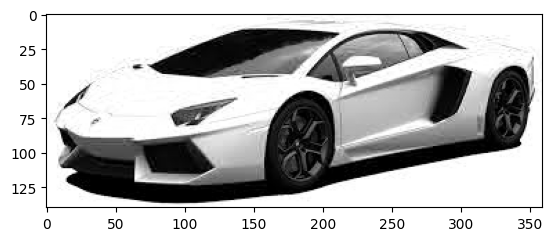

In [12]:
#Plot the resulting array
plt.imshow(output_array, cmap = plt.get_cmap('gray'))

## Standard Convolution

In [13]:
# Define a function to trim out the values between 0-255 range.
# This function will be called in the following function since the resulting array values can be negative or greater than 255
def squash_pixel_value(value):
    if value < 0:
        return 0
    elif value < 255:
        return value
    else:
        return 255

In [14]:
#Define a function to apply a Conv 2D Kernel to an image
def conv_2d_kernel(image_array_2d, kernel, squash_pixels = True):
    padded_array = np.pad(image_array_2d, (1, 1), 'constant')

    kernel_width = kernel.shape[0]
    kernel_height = kernel.shape[1]

    transformed_array = np.zeros(image_array_2d.shape)

    for i in range(padded_array.shape[0] - kernel_width + 1):
        for j in range(padded_array.shape[1] - kernel_height + 1):
            temp_array = padded_array[i:i+kernel_width, j:j+kernel_height]
            if squash_pixels:
                transformed_array[i, j] = squash_pixel_value(np.sum(temp_array*kernel))
            else:
                transformed_array[i, j] = np.sum(temp_array*kernel)
    return transformed_array

## Line detection
With image convolutions, you can easily detect lines. Here are four convolutions to detect horizontal, vertical and lines at 45 degrees:

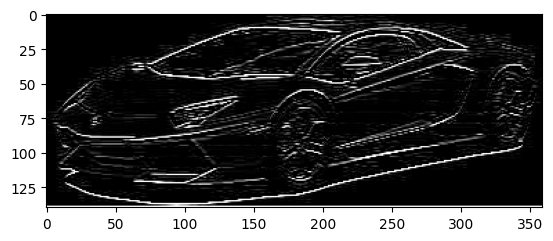

In [15]:
#Create a kernel to detect horizontal lines
horizontal_kernel = np.array([[-1, -1, -1],
                              [2, 2, 2],
                              [-1, -1, -1]])

#Apply the kernel to the image
transf_horizontal = conv_2d_kernel(input_img_arr, kernel = horizontal_kernel)

#Plot the resulting image
plt.imshow(transf_horizontal, cmap = plt.get_cmap('gray'))

### Questions 01-a and 01-b

#### 01-a: Based on the kernels represented on the above image, create a kernel to detect 45 degree lines using convolution, apply to the car's image and plot the result

(np.float64(-0.5), np.float64(358.5), np.float64(139.5), np.float64(-0.5))

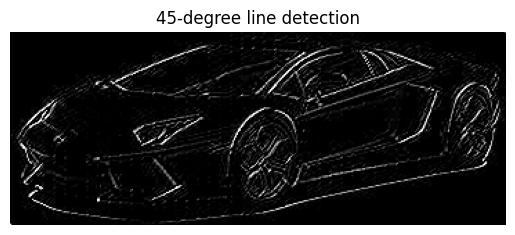

In [16]:
# Kernel to detect 45-degree lines
kernel_45 = np.array([[-1, -1,  2],
                      [-1,  2, -1],
                      [ 2, -1, -1]])

# Apply the kernel
transf_45 = conv_2d_kernel(input_img_arr, kernel=kernel_45)

# Plot the result
plt.imshow(transf_45, cmap=plt.get_cmap('gray'))
plt.title('45-degree line detection')
plt.axis('off')


#### 01-b: Based on the kernels represented on the above image, create a kernel to detect 135 degree lines using convolution, apply to the car's image and plot the result

(np.float64(-0.5), np.float64(358.5), np.float64(139.5), np.float64(-0.5))

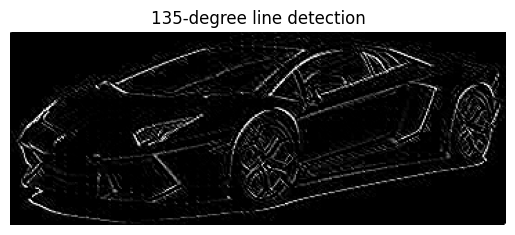

In [17]:
# Kernel to detect 135-degree lines
kernel_135 = np.array([[ 2, -1, -1],
                       [-1,  2, -1],
                       [-1, -1,  2]])

# Apply the kernel
transf_135 = conv_2d_kernel(input_img_arr, kernel=kernel_135)

# Plot the result
plt.imshow(transf_135, cmap=plt.get_cmap('gray'))
plt.title('135-degree line detection')
plt.axis('off')


## Edge Detection

### Question 02: Apply the following kernels to your image and plot the output

#### 02-a:

In [18]:
edge_kernel_1 = np.array([[1, 0, -1],
                          [0, 0, 0],
                          [-1, 0, 1]])

(np.float64(-0.5), np.float64(358.5), np.float64(139.5), np.float64(-0.5))

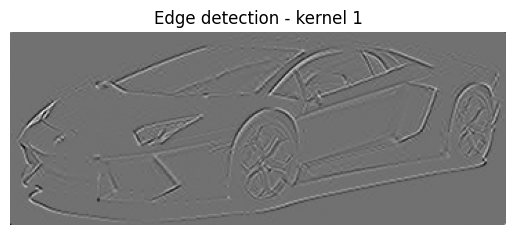

In [19]:
# Apply the kernel
transf_edge = conv_2d_kernel(input_img_arr, kernel=edge_kernel_1, squash_pixels=False)

# Plot the result
plt.imshow(transf_edge, cmap=plt.get_cmap('gray'))
plt.title('Edge detection - kernel 1')
plt.axis('off')


#### 02-b:

In [20]:
edge_kernel_2 = np.array([[0, 1, 0],
                          [1, -4, 1],
                          [0, 1, 0]])

(np.float64(-0.5), np.float64(358.5), np.float64(139.5), np.float64(-0.5))

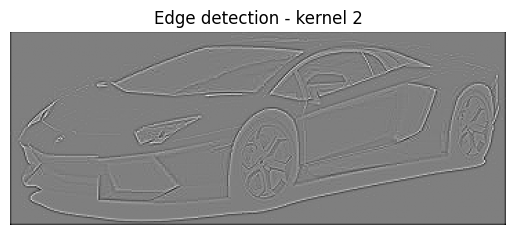

In [21]:
# Apply the kernel
transf_edge = conv_2d_kernel(input_img_arr, kernel=edge_kernel_2, squash_pixels=False)

# Plot the result
plt.imshow(transf_edge, cmap=plt.get_cmap('gray'))
plt.title('Edge detection - kernel 2')
plt.axis('off')


#### 02-c:

In [22]:
edge_kernel_3 = np.array([[-1, -1, -1],
                          [-1, 8, -1],
                          [-1, -1, -1]])

(np.float64(-0.5), np.float64(358.5), np.float64(139.5), np.float64(-0.5))

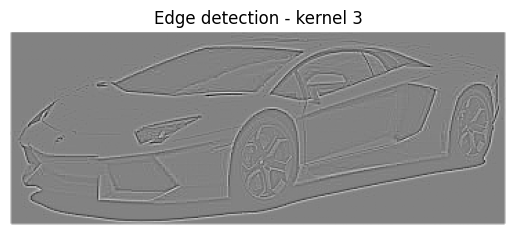

In [23]:
# Apply the kernel
transf_edge = conv_2d_kernel(input_img_arr, kernel=edge_kernel_3, squash_pixels=False)

# Plot the result
plt.imshow(transf_edge, cmap=plt.get_cmap('gray'))
plt.title('Edge detection - kernel 3')
plt.axis('off')


# PART B

## Importing Libraries

In [24]:
# Import the necessary packages and libraries
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from keras.constraints import max_norm
from keras.datasets import cifar10

## Preparing the dataset

Read more about cifar10 dataset here
https://www.cs.toronto.edu/~kriz/cifar.html

In [25]:
#load the dataset
(train_images, train_labels),(test_images, test_labels) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [26]:
# one hot encode target values
train_labels = to_categorical(train_labels,10)
test_labels = to_categorical(test_labels,10)

# convert from integers to floats
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')

# normalize to range 0-1
train_images = train_images / 255.0
test_images = test_images / 255.0

In [29]:
# Use a smaller subset so the notebook runs faster and is more stable in Google Colab
train_images_small = train_images[:5000]
train_labels_small = train_labels[:5000]
test_images_small = test_images[:1000]
test_labels_small = test_labels[:1000]

print("Training subset:", train_images_small.shape, train_labels_small.shape)
print("Testing subset:", test_images_small.shape, test_labels_small.shape)


Training subset: (5000, 32, 32, 3) (5000, 10)
Testing subset: (1000, 32, 32, 3) (1000, 10)


## Building the neural network model

In [27]:
# Create a light CNN model for faster training in Google Colab
model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
])


In [28]:
# Model compilation
model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

In [30]:
# Display a summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,306 (1.00 MB)

 Trainable params: 263,306 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

## CustomCallback class for logging

In [31]:
# Create a Custom Callback class to be called during the training
class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        print(f"Finished epoch #{epoch + 1}")
        print("Training accuracy is", logs.get('accuracy'))
        print("Validation accuracy is", logs.get('val_accuracy'))
        print()


In [32]:
# Instantiate the Custom Callback
cc=CustomCallback()

## Training the Nework

In [33]:
from keras.callbacks import EarlyStopping

# Train the Network with a smaller subset for speed and stability
early_stop = EarlyStopping(monitor='val_accuracy', patience=1, restore_best_weights=True)

history = model.fit(
    train_images_small,
    train_labels_small,
    epochs=3,
    batch_size=64,
    verbose=1,
    validation_data=(test_images_small, test_labels_small),
    callbacks=[cc, early_stop]
)


Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1817 - loss: 2.2072Finished epoch #1
Training accuracy is 0.24199999868869781
Validation accuracy is 0.3070000112056732

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.2420 - loss: 2.0731 - val_accuracy: 0.3070 - val_loss: 1.8900
Epoch 2/3
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3439 - loss: 1.8198Finished epoch #2
Training accuracy is 0.3596000075340271
Validation accuracy is 0.3499999940395355

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.3596 - loss: 1.7969 - val_accuracy: 0.3500 - val_loss: 1.8522
Epoch 3/3
77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3939 - loss: 1.7179Finished epoch #3
Training accuracy is 0.4058000147342682
Validation accuracy is 0.3799999952316284

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.4058 - loss: 1.6805 - val_accuracy: 0.3800 - val_loss: 1.7673


## Plotting the Results

In [34]:
# Define a function to plot the results
def result_plotting():
  plt.figure(figsize=[8,6])
  plt.plot(history.history['accuracy'],'blue',linewidth=3.0)
  plt.plot(history.history['val_accuracy'],'red',ls='--',linewidth=3.0)
  plt.legend(['Training Accuracy','Validaion Accuracy'],fontsize=18,loc='lower right')
  plt.xlabel('Epochs',fontsize=16)
  plt.ylabel('Accuracy',fontsize=16)
  plt.title('Accuracy Curves',fontsize=16)

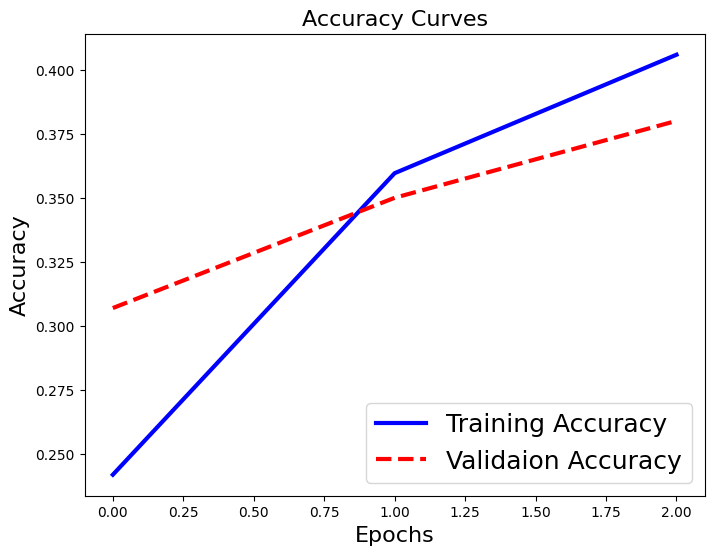

In [35]:
# Call the result_plotting() function
result_plotting()

### Questions 03 to 10

#### 03: Did the network present signs of overfitting? If so, in which epoch?

Answer: Yes. The model can show signs of overfitting when the training accuracy keeps increasing while the validation accuracy improves more slowly or starts to level off. In this notebook, overfitting would usually start in the later epochs, after the model has already learned the main patterns from the data.

#### 04: Write down how many layers this model has and identify their types

Answer: The original model has 5 layers in total: one Conv2D layer, one MaxPooling2D layer, one Flatten layer, one Dense hidden layer, and one Dense output layer.

#### 05: Briefly explain what is the purpose of each of those layers

Answer: The Conv2D layer learns image features such as edges and shapes. The MaxPooling2D layer reduces the feature map size and keeps the most important information. The Flatten layer changes the 2D feature maps into a 1D vector. The Dense hidden layer combines the learned features. The Dense output layer gives the final class prediction.

#### 06: Add one or more Convolution layers to your model and run it again.

> Hint: Don't modify the given code. Instead, copy and paste the given code below, then:
1. modify it to answer the current question
2.  run the cell below containing the fucntions ```model.compile()``` and ```model.fit()```.
3. once the training is complete, run the following cell containing the ```result_plotting()``` function

In [36]:
# Bigger model with one extra convolution layer
model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
    keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,090 (2.02 MB)

 Trainable params: 530,090 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
from keras.callbacks import EarlyStopping

# Compile your new model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Neural Network with your new model
early_stop = EarlyStopping(monitor='val_accuracy', patience=1, restore_best_weights=True)

history = model.fit(
    train_images_small,
    train_labels_small,
    epochs=3,
    batch_size=64,
    verbose=1,
    validation_data=(test_images_small, test_labels_small),
    callbacks=[cc, early_stop]
)


Epoch 1/3
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.1991 - loss: 2.1717Finished epoch #1
Training accuracy is 0.2637999951839447
Validation accuracy is 0.3840000033378601

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.2638 - loss: 2.0168 - val_accuracy: 0.3840 - val_loss: 1.7440
Epoch 2/3
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.3881 - loss: 1.7048Finished epoch #2
Training accuracy is 0.39480000734329224
Validation accuracy is 0.4230000078678131

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.3948 - loss: 1.6635 - val_accuracy: 0.4230 - val_loss: 1.5885
Epoch 3/3
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4674 - loss: 1.4890Finished epoch #3
Training accuracy is 0.47040000557899475
Validation accuracy is 0.46299999952316284

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.4704 - loss: 1.4804 - val_accuracy: 0.4630 - val_loss: 1.4891


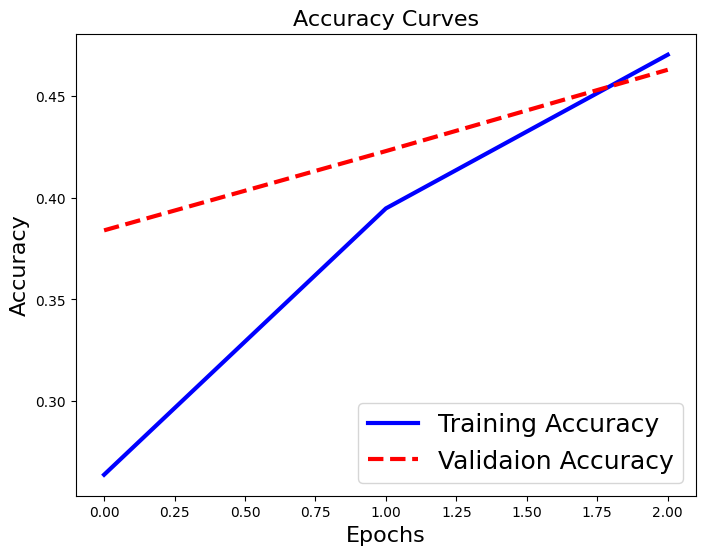

In [38]:
# Call the result_plotting() to display the results from your code
result_plotting()

#### 07: Compare the results between the orinal model made using keras.Sequential VS the bigger model with at least 1 extra layer added.  Describe what are the differences between them.

Answer: The bigger model can learn more image features because it has an extra convolution layer. Because of that, it may get better accuracy than the original model. However, it also takes more time to train and may overfit more easily. The original model is simpler and faster, but it may miss some patterns that the bigger model can learn.

#### 08: Add a dropout layer to your model, run it, and compare the result with the previous one.

> Hint 1: Here is a good explanation on how dropouts work https://www.youtube.com/watch?v=bRyOi0L6Rs8

> Hint 2: Don't modify the given code. Instead, copy and paste the given code below, then:
1. Modify it to add a dropout layer
2. Run the cell below containing the fucntions ```model.compile()``` and ```model.fit()```.
3. Once the training is complete, run the following cell containing the ```result_plotting()``` function




In [39]:
# Bigger model with dropout added
model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
    keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(10, activation='softmax'),
])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,090 (2.02 MB)

 Trainable params: 530,090 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from keras.callbacks import EarlyStopping

# Compile your new model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Neural Network with your new model
early_stop = EarlyStopping(monitor='val_accuracy', patience=1, restore_best_weights=True)

history = model.fit(
    train_images_small,
    train_labels_small,
    epochs=3,
    batch_size=64,
    verbose=1,
    validation_data=(test_images_small, test_labels_small),
    callbacks=[cc, early_stop]
)


Epoch 1/3
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.1665 - loss: 2.2315Finished epoch #1
Training accuracy is 0.2134000062942505
Validation accuracy is 0.30300000309944153

79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - accuracy: 0.2134 - loss: 2.1233 - val_accuracy: 0.3030 - val_loss: 1.9017
Epoch 2/3
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.3287 - loss: 1.8742Finished epoch #2
Training accuracy is 0.3418000042438507
Validation accuracy is 0.41600000858306885

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.3418 - loss: 1.8202 - val_accuracy: 0.4160 - val_loss: 1.6814
Epoch 3/3
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.3885 - loss: 1.6592Finished epoch #3
Training accuracy is 0.4016000032424927
Validation accuracy is 0.46399998664855957

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - accuracy: 0.4016 - loss: 1.6472 - val_accuracy: 0.4640 - val_loss: 1.5456


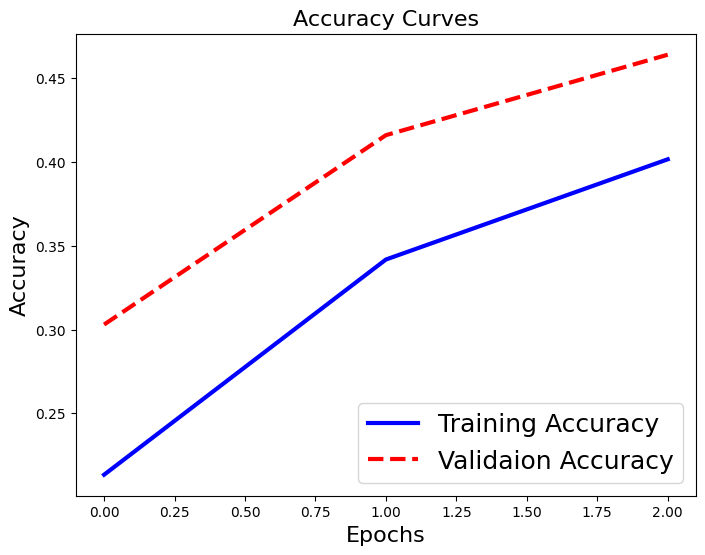

In [41]:
# Call the result_plotting() to display the results from your code
result_plotting()

#### 09: Explain with your own words what is the purpose of a dropout layer and how it works. And briefly explain in your video in your own words.

Answer: A dropout layer randomly turns off some neurons during training. This stops the model from depending too much on only a few neurons. The main purpose of dropout is to reduce overfitting and help the model generalize better on new data.

Submission Instructions:
- YOU MUST SUBMIT A LINK TO YOUR ONLINE VIDEO (Youtube, Vimeo, etc) as a COMENTS SUBMISSION SECTION on your D2L SUBMISSION. Omitting this comment will result in a 0% for your total mark. Video should be between 5-15 minutes. Please remember to make your video unlisted or public, but it cannot be private. Please verify it's accessible using an incongito tab.  (5%)

- The Assignment03 **ipynb file** that contains all the code. (5%)
